# Plot 1: Phase Plots

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_band(ax, xarray, yarray, phase_lower, phase_higher,
              arrow=False, arrow_pos=0, hatch='', double=False):
    # Main curve
    ax.plot(xarray, yarray, color="black", linewidth=1, label=r'$\epsilon_k$')

    # Fills
    ax.fill_between(
        xarray, np.clip(yarray, phase_higher, 1), 1,
        facecolor="#ff2222", alpha=0.7,
        hatch=hatch, edgecolor="gray", linewidth=0.0,
        label="Empty"
    )
    ax.fill_between(
        xarray, np.clip(yarray, phase_lower, phase_higher), phase_higher,
        alpha=0.6, color="#23d544",
        where=(yarray <= phase_higher),
        label="Singly Occupied"
    )
    ax.fill_between(
        xarray, np.clip(yarray, -1, phase_lower), phase_lower,
        alpha=0.5, color="#1048ff",
        where=(yarray <= phase_lower),
        label="Doubly Occupied"
    )

    # Horizontal dashed lines
    ax.hlines(phase_higher, -np.arccos(-phase_higher), np.arccos(-phase_higher),
              colors="black", linestyles="dashed", linewidth=1)
    ax.hlines(phase_lower, -np.arccos(-phase_lower), np.arccos(-phase_lower),
              colors="black", linestyles="dashed", linewidth=1)

    # Optional arrow
    if arrow:
        ax.annotate(
            '', xy=(arrow_pos, phase_higher), xycoords='data',
            xytext=(arrow_pos, phase_lower), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(arrow_pos + 0.1, (phase_lower + phase_higher)/2,
                r"$U$", va="center", ha="left")
        
    if double == True:
        ax.text(np.arccos(-phase_lower) + 0.1, phase_lower - 0.05,
                r'$\epsilon_{k_F}$', va="center", ha="left")
    else:
        if phase_lower != -1:    
            ax.text(np.arccos(-phase_lower) + 0.1, phase_lower,
                    r'$\epsilon_{D}$', va="center", ha="left")
        if phase_higher != 1:
            ax.text(np.arccos(-phase_higher) + 0.1, phase_higher,
                    r'$\epsilon_{S}$', va="center", ha="left")
        

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks([-np.pi, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$\pi$"])
    ax.set_yticks([])

    # Local legend: only the curve
    #ax.legend(handles=[ax.get_lines()[0]],
    #          loc="lower left", frameon=False, markerfirst=True)


def plot_occupation_numbers(ax, k0, k1, klabels=False, double=False):
    k0 *= np.pi
    k1 *= np.pi
    x = np.linspace(-np.pi, np.pi, 5000)

    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    f = np.piecewise(
        x,
        [np.abs(x) < k0, (np.abs(x) >= k0) & (np.abs(x) < k1), np.abs(x) >= k1],
        [2, 1, 0]
    )

    line, = ax.plot(x, f, color="black", linewidth=1, label=r'$n_k$', zorder=2)

    # Fills
    mask = (x >= -k0) & (x <= k0)
    ax.fill_between(x[mask], 0, 2,
                    alpha=0.5, color="#bdffe6", label="Doubly Occupied")
    ax.fill_between(x, 0, 1,
                    alpha=0.4, color="#fff0ab", where=(f == 1),
                    label="Singly Occupied")
    ax.fill_between(x, 0.5, 0,
                    alpha=0.5, color="#f2f0f0", where=(f == 0),
                    label="Empty")

    # Local legend: only the curve
    ax.legend(handles=[line], loc="upper right", frameon=False)

    if klabels == True:
    # Axis ticks/labels:

        ax.set_xticks([-np.pi, -k1, -k0, k0, k1, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-k_1$", r"$-k_0$",
                            r"$k_0$", r"$k_1$", r"$\pi$"])
        ax.set_yticks([1])
        ax.text(-0.2, 2.1, "2", ha="right", va="center",
                zorder=10, clip_on=False, transform=ax.transData)
        
        ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)        
    else:
        """
        ax.set_xticks([-np.pi, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$\pi$"])
        """
        if k1 == np.pi:
            if k0 != 0:
                ax.set_yticks([1])
                ax.text(-0.2, 2.1, "2", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
                ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)
                ax.set_xticks([-np.pi,-k0, k0, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$-k_0$", r"$k_0$", r"$\pi$"])
            else:
                ax.set_yticks([2])
                ax.text(-0.2, 1.1, "1", ha="right", va="center",
                        zorder=10, clip_on=False, transform=ax.transData)
                ax.set_xticks([-np.pi, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$\pi$"])
        else:
            if k0 == 0:
                ax.set_xticks([-np.pi,-k1, k1, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$-k_1$", r"$k_1$", r"$\pi$"])
                ax.set_yticks([2])
                ax.text(-0.2, 1.1, "1", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
            else:
                ax.set_yticks([1])
                ax.text(-0.2, 2.1, "2", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
                if k1 != k0:
                    ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)
                    ax.set_xticks([-np.pi,-k0, k0, np.pi])
                    ax.set_xticklabels([r"$-\pi$", r"$-k_0$", r"$k_0$", r"$\pi$"])

    if double == True:
        ax.set_yticks([1])
        ax.text(-0.2, 2.1, "2", ha="right", va="center",
                zorder=10, clip_on=False, transform=ax.transData)
        ax.set_xticks([-np.pi,-k1, k1, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-k_F$", r"$k_F$", r"$\pi$"])


    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(0, 2.2)



k = np.linspace(-np.pi, np.pi, 1000)
eps_k = -np.cos(k)



<>:130: SyntaxWarning: invalid escape sequence '\p'
<>:130: SyntaxWarning: invalid escape sequence '\p'
/var/folders/6g/kfvfxvvs2473z8z47g0kr34w0000gn/T/ipykernel_1929/1888250279.py:130: SyntaxWarning: invalid escape sequence '\p'
  """


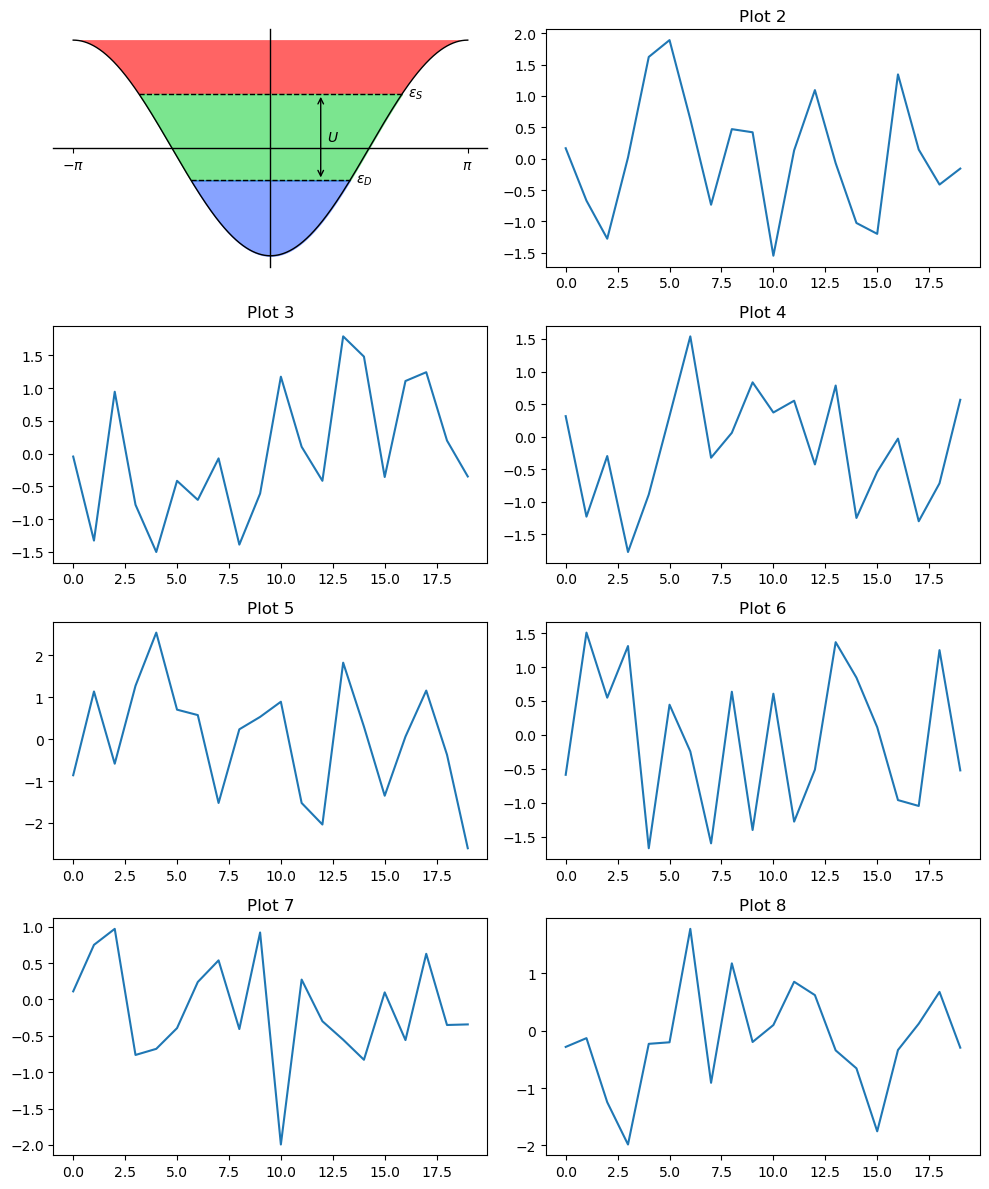

In [18]:
# 1. Create the grid (4 rows, 2 columns)
# figsize=(width, height) - adjust this to make it look less cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 12))

# 2. Flatten the axes array for easy iteration
# 'axes' is a 2D array (4x2), flattening it makes it 1D (length 8)
axes_flat = axes.flatten()

# 3. Loop through and plot your data
plot_band(axes_flat[0], k, eps_k, -0.3, 0.5, arrow=True, arrow_pos=0.8)

for i in range(1, 8):
    ax = axes_flat[i]
    ax.plot(np.random.randn(20)) # Replace with your data
    ax.set_title(f'Plot {i+1}')

# 4. Critical step: Use tight_layout to prevent overlapping labels
plt.tight_layout()
plt.show()